In [1]:
# Generic packages
import numpy as np 
import matplotlib.pyplot as plt
from os import listdir
import pickle

# Style 
#%config InlineBackend.figure_formats=['svg']
plt.style.use('seaborn-pastel')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.model_selection import train_test_split
from sklearn.manifold import Isomap, TSNE, SpectralEmbedding, LocallyLinearEmbedding, MDS
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering, AffinityPropagation, MeanShift
from sklearn.cross_decomposition import CCA, PLSCanonical

from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

from tqdm.notebook import tqdm
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

C:\Users\dalbe\AppData\Local\Temp\ipykernel_15328\4132840905.py:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-pastel')


### Functions

In [2]:
def build_dataset(path):
    """
    build_dataset(path)

        Import dataset from path, normalize data and separate in train and test datasets.

        -path (str) : Path to the dataset files. 
    """
    #496
    X = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.float16).reshape(-1,250) for fileName in listdir(path)])
    X = X.astype("double")
    shape = np.shape(X)

    print(f"Dataset contains :",
        f"\nSamples : {shape[0]}",
        f"\nLenght of samples : {shape[1]}",
        f"\nNumber of samples : {len(X)}")
    
    return X

In [3]:
def reduction(X,function,plot=True, **param):
    """
    # reduction(X,function,plot=False,**param)

    Verifies if a function has been saved in the `DR preprocess` folder to avoid unnecessary computation. 

    -X (array-like, sparse matrix) : Inputs of the function that needs to be computed.
    -function (function) : Function that is executed.
    -param (**kwargs) : Multiple keyword arguments to define the parameters of `function`.
    
    """
    # File name
    file_name = f"{str(function.__name__)}_{str(param.items())}"
    print("File name : ", file_name)

    # Check for existing file
    #try:
    #    result = np.load(f"DR preprocess\{file_name}.npy",allow_pickle=True)

    # Compute operation if file does not exist
    #except:
    method = function(**param)
    
    try:
        trained = method.fit(X[::10])
        result = trained.transform(X)
    except:
        result = method.fit_transform(X[::10])
            
    #np.save(f"DR preprocess\{file_name}",arr=result)
    
    # Plot results
    if plot:
        plt.hist(result, bins=1000)
        #plt.scatter(result[:, 0], result[:, 1],alpha=0.005)
        #plt.xlabel('Feature 1')
        #plt.ylabel('Feature 2')

    return result

In [4]:
def silhouette_kmean(X, min_cluster, max_cluster):

        scores = []

        for cluster_number in tqdm(range(min_cluster+1,max_cluster+1) , desc="Clusters") :
            clusters = KMeans(n_clusters=cluster_number , n_init="auto").fit_predict(X[::10])
            scores.append(silhouette_score(X[::10], clusters))

        optimal_cluster = np.argmax(scores) + 1

        labels = KMeans(n_clusters=optimal_cluster, n_init="auto").fit_predict(X)

        print("Optimal number of cluster : ", optimal_cluster)
        #plt.figure()
        #bins = np.linspace(min(X), max(X), 1_000).reshape(-1)

        #for index_cluster, cluster in enumerate(labels):
        #    plt.hist(cluster , bins, alpha = 0.5, label=f"{index_cluster}")
        #plt.xlabel("feature")
        #plt.ylabel("counts")
        #plt.legend(ncol=3)
        #plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap='Pastel2', alpha=0.01)
        #plt.xlabel('Feature 1')
        #plt.ylabel('Feature 2')
        #plt.show()

In [5]:
def clustering(X, function, label_return = False, **param):
    """
    # clustering(X,function,**param)

        Run and plot a clustering technique defined with the function parameter.
        The process is based on `sklearn` structure.

    -X (array-like, sparse matrix) : Inputs of the function that needs to be computed.
    -function (function) : Function that is executed.
    -param (**kwargs) : Multiple keyword arguments to define the parameters of `function`.
    """

    labels = function(**param).fit_predict(X)

    plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap='Pastel2', alpha=0.05)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    if label_return:
        return label_return


### Plot TES

Dataset contains : 
Samples : 143360 
Lenght of samples : 250 
Number of samples : 143360


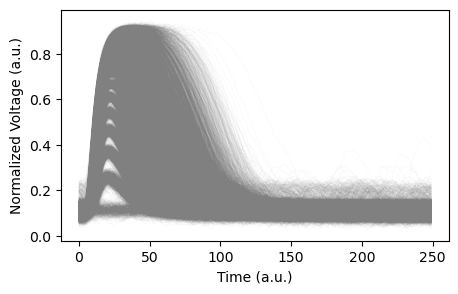

In [6]:
X = build_dataset("Datasets/NIST (250)/")

plt.figure(figsize=(5,3))
plot = [plt.plot(i,alpha=0.05, color=[0.5,0.5,0.5], linewidth=0.5) for i in X[::10]]


plt.ylabel("Normalized Voltage (a.u.)")
plt.xlabel("Time (a.u.)")
plt.show()

#plt.savefig('Trace_Oxford.png', transparent=True)

### Principal Component Analysis (PCA)

File name :  PCA_dict_items([('n_components', 1)])


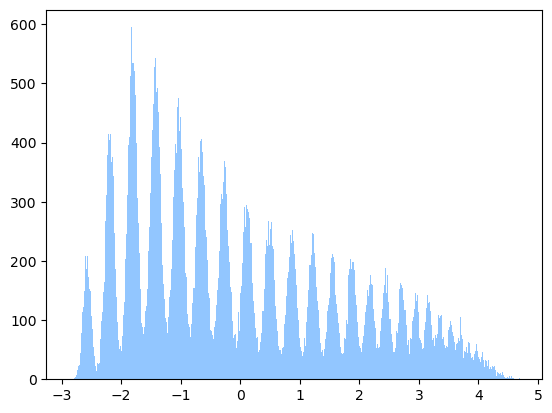

In [7]:
X_pca = reduction(np.copy(X),PCA,n_components=1)
#silhouette_kmean(X_pca, 10, 30)

### Kernel 

#### Polynomial

File name :  KernelPCA_dict_items([('n_components', 1), ('kernel', 'poly')])


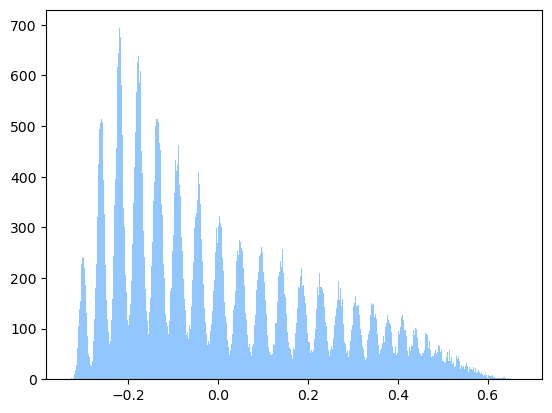

In [8]:
X_kernel_poly = reduction(np.copy(X),KernelPCA,n_components=1, kernel="poly")
#silhouette_kmean(X_kernel_poly, 10, 30)

#### Radial basis function (RBF)

File name :  KernelPCA_dict_items([('n_components', 1), ('kernel', 'rbf'), ('gamma', 0.02)])


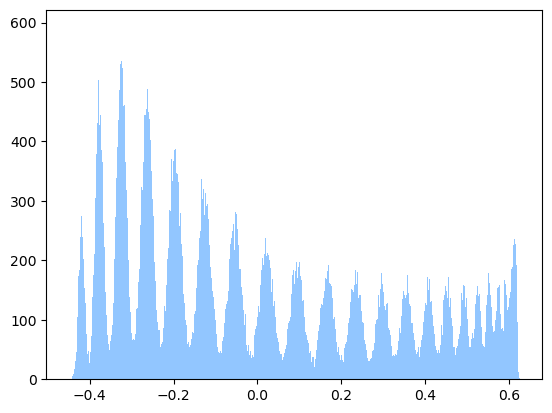

In [9]:
X_kernel_rbf = reduction(np.copy(X),KernelPCA,n_components=1,kernel="rbf",gamma=0.02)
#silhouette_kmean(X_kernel_rbf, 10, 30)

#### Sigmoid

File name :  KernelPCA_dict_items([('n_components', 1), ('kernel', 'sigmoid'), ('gamma', 0.02)])


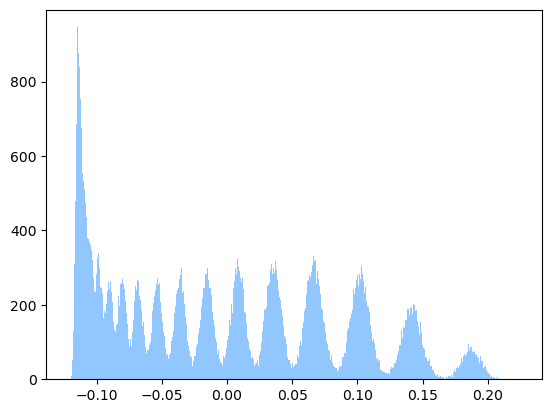

In [10]:
X_kernel_sigmoid = reduction(np.copy(X),KernelPCA,n_components=1,kernel="sigmoid",gamma=0.02)
#silhouette_kmean(X_kernel_sigmoid, 10, 30)

#### Cosine

File name :  KernelPCA_dict_items([('n_components', 1), ('kernel', 'cosine'), ('gamma', 0.02)])


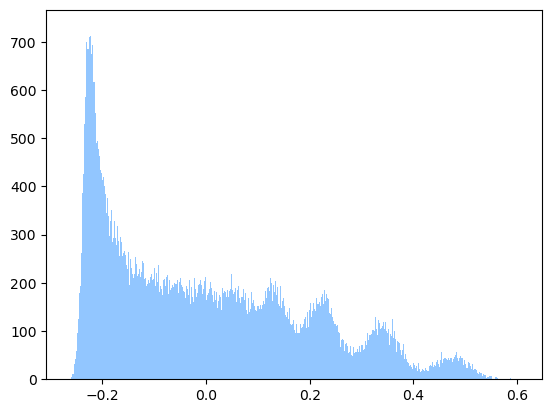

In [11]:
X_kernel_cosine = reduction(np.copy(X),KernelPCA,n_components=1,kernel="cosine",gamma=0.02)
#silhouette_kmean(X_kernel_cosine, 10, 30)

### t-distributed Stochastic Neighbor Embedding (t-SNE)



File name :  TSNE_dict_items([('random_state', 42), ('n_components', 1), ('init', 'random')])


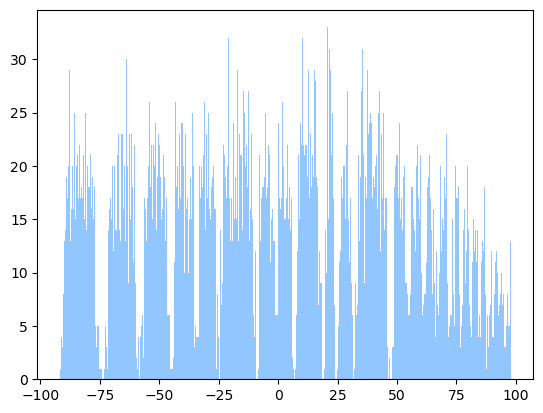

In [12]:
X_tsne = reduction(np.copy(X),TSNE,random_state=42,n_components=1,init="random", plot=True)
#silhouette_kmean(X_tsne, 10, 30)

### Non-Negative Matrix Factorization (NMF)

File name :  NMF_dict_items([('n_components', 1), ('alpha_W', 0.1), ('random_state', 42)])


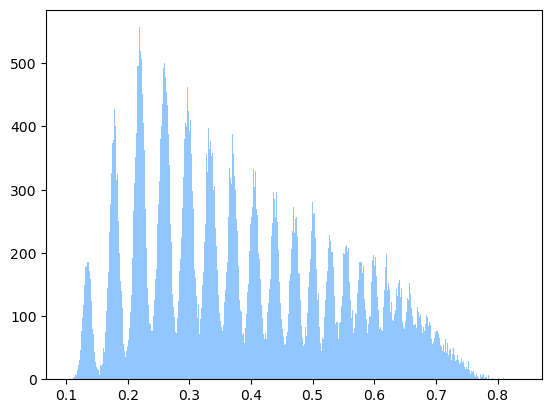

In [13]:
X_NMF = reduction(np.copy(X),NMF,n_components=1,alpha_W=0.1,random_state=42, plot=True)
#silhouette_kmean(X_NMF, 10, 30)

### Isomap

File name :  Isomap_dict_items([('n_neighbors', 20), ('n_components', 1), ('eigen_solver', 'arpack')])


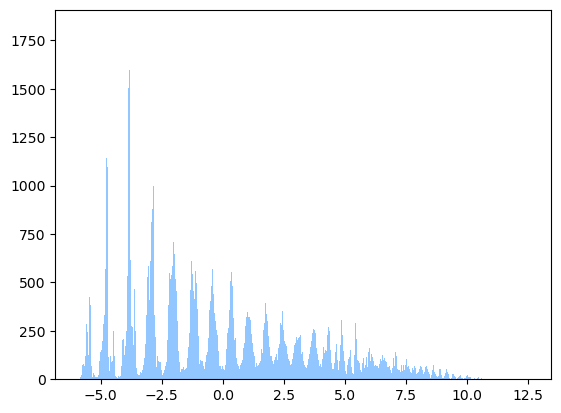

In [14]:
X_Isomap = reduction(np.copy(X),Isomap, plot=True,n_neighbors=20, n_components=1, eigen_solver="arpack")
#silhouette_kmean(X_Isomap, 10, 30)

### Multidimensional scaling

File name :  MDS_dict_items([('n_components', 1), ('max_iter', 10)])


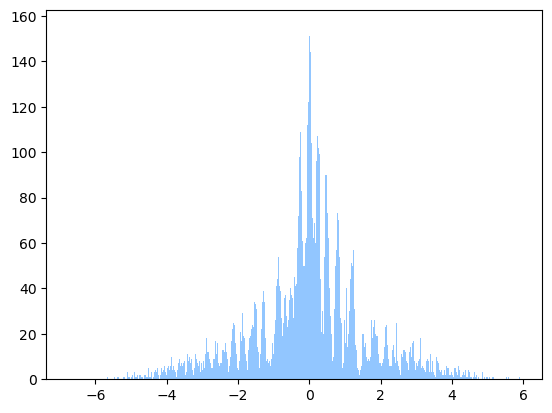

In [15]:
X_MDS = reduction(np.copy(X),MDS,plot=True,n_components=1,max_iter=10)
#silhouette_kmean(X_MDS, 10, 30)

### Locally Linear Embedding (LLE)

File name :  LocallyLinearEmbedding_dict_items([('n_components', 1)])


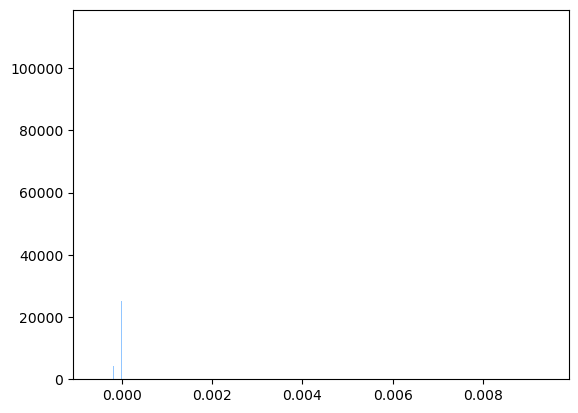

In [16]:
X_LLE = reduction(np.copy(X),LocallyLinearEmbedding, plot=True,n_components=1)
#silhouette_kmean(X_LLE, 10, 30)

### Canonical Correlation Analysis (CCA)

In [17]:
X_CCA = reduction(np.copy(X),CCA,n_components=1)

File name :  CCA_dict_items([('n_components', 1)])


ValueError: Input Y contains NaN.

### Custom autoencoder

In [ ]:
def open_object(file_name):
        """
        # open_object

        open_object(file_name)

        Open a file using the Pickle library. 
        Is used in this context for files containing dictionaries.

        Parameters
        ----------
        - file_name : str
                - Name of the file to open.

        Returns
        -------
        None
        """
        try:
            with open(file_name, 'rb') as f:
                dictionary = pickle.load(f)
        except Exception as ex:
            print("Error when loading file : ", ex)

        return dictionary

In [ ]:
date_time = "run-2023-08-28-08-18/fold 0"
path_save = f"Autoencoder Log/{date_time}/"

X_autoencoder = open_object(f"{path_save}/results.bin")['encode']

x = plt.hist(X_autoencoder, bins=500)
plt.ylabel("Counts")
plt.xlabel("Feature")
#plt.savefig('demo.png', transparent=True)
#clustering(X_autoencoder,DBSCAN, eps=0.0201,min_samples = 30)

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(5,2),dpi=200)

scores, X, optimal_cluster = silhouette_kmean(X_autoencoder, 40)
print(f"Optimal number : {optimal_cluster}")

bins = np.linspace(min(X_autoencoder), max(X_autoencoder), 1000)

for index, cluster in enumerate(X):
    plt.hist(cluster , bins, alpha = 0.5)

plt.xlabel("feature")
plt.ylabel("counts")

plt.figure(figsize=(5,2),dpi=200)

plt.plot(range(2, len(scores)+2), scores)
plt.ylabel("Silhouette score")
plt.xlabel("Number of cluster")